# opfunu 测试函数 API 入门

以 **Ackley01（3 维）** 为例：输入一个候选解向量，返回一个标量目标值，目标是最小化。已知最优解为全零向量，最优值为 0（计算结果可能有浮点误差）。

本例按项目 `.venv` 中的 **opfunu 1.0.1** 编写并运行。请选择项目的 `.venv` Python 内核。
若导入提示缺少 `pkg_resources`，可在 notebook 中运行 `%pip install "setuptools<81"` 后重启内核；当前环境已补齐该依赖。导入时可能仍有弃用警告。

参考：[官方 API 文档](https://opfunu.readthedocs.io/en/stable/pages/benchmark.html)、[官方示例](https://github.com/thieu1995/opfunu/blob/master/examples.md)。新版文档中的部分名称可能与本地版本不同。

In [1]:
import inspect
from typing import cast
import numpy as np
import opfunu
from opfunu.name_based import Ackley01

np.set_printoptions(precision=4, suppress=True)
func = Ackley01(ndim=3)
# opfunu 的基类先将维度设为 None；构造后检查并保存整数维度。
raw_ndim = func.ndim
assert isinstance(raw_ndim, int)
ndim: int = raw_ndim
print("opfunu 版本:", opfunu.__version__)
print("构造函数:", inspect.signature(Ackley01))
print("函数名称:", func.name)
print("维度:", func.ndim)
print("每一维的下界:", func.lb)
print("每一维的上界:", func.ub)
print("bounds（每行是该维度的 [下界, 上界]）:\n", func.bounds)
print("已知最优解:", func.x_global)
print("已知最优值:", func.f_global)

opfunu 版本: 1.0.1
构造函数: (ndim=None, bounds=None)
函数名称: Ackley 01
维度: 3
每一维的下界: [-35. -35. -35.]
每一维的上界: [35. 35. 35.]
bounds（每行是该维度的 [下界, 上界]）:
 [[-35.  35.]
 [-35.  35.]
 [-35.  35.]]
已知最优解: [0. 0. 0.]
已知最优值: 0.0


/Users/junwei/workspace/demos/py-labs/.venv/lib/python3.14/site-packages/opfunu/cec_based/cec.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 常用接口

| API | 用途 |
| --- | --- |
| `Ackley01(ndim=3, bounds=None)` | 创建测试函数；`ndim` 为变量个数 |
| `func.evaluate(x)` | 对一个长度为 `ndim` 的一维 NumPy 数组求值 |
| `func.ndim`、`func.lb`、`func.ub`、`func.bounds` | 读取维度与搜索边界；`bounds` 的形状是 `(ndim, 2)` |
| `func.x_global`、`func.f_global` | 读取已知最优解与最优值 |
| `func.create_solution()` | 在边界内随机产生一个候选解，不求值 |
| `func.is_succeed(x, tol=1e-5)` | 根据边界和目标值误差判断是否成功；内部也会求值 |
| `func.n_fe` | 累计函数求值次数 |
| `func.get_paras()` | 返回维度、边界及函数特有参数 |

请自行保证候选解的形状及边界合法，不要依赖所有函数都会检查或裁剪输入。`evaluate` 按单个向量调用；一批候选解可循环求值。

In [2]:
x = np.array([1.0, 2.0, 3.0])
assert x.shape == (func.ndim,)
assert np.all((x >= func.lb) & (x <= func.ub))

# 明确这是运行时整数，避免 notebook 中被误判为类型别名。
evaluation_count_before: int = func.n_fe
value = func.evaluate(x)
print("候选解:", x)
print("目标值:", value)
print("本次求值次数:", func.n_fe - evaluation_count_before)

opt_value = func.evaluate(func.x_global)
print("最优解处的目标值:", opt_value)
print("是否达到最优值:", func.is_succeed(func.x_global, tol=1e-5))
print("累计求值次数（含 is_succeed 内部求值）:", func.n_fe)
assert np.isclose(opt_value, func.f_global, atol=1e-10)

# create_solution 使用 NumPy 全局随机状态；种子使这一演示可重复。
np.random.seed(42)
x_random = func.create_solution()
print("随机候选解:", x_random)
print("随机候选解的目标值:", func.evaluate(x_random))
print("函数参数:", func.get_paras())

候选解: [1. 2. 3.]
目标值: 7.0164536082694
本次求值次数: 1
最优解处的目标值: 4.440892098500626e-16
是否达到最优值: True
累计求值次数（含 is_succeed 内部求值）: 3
随机候选解: [-8.7822 31.55   16.2396]
随机候选解的目标值: 21.628663482018595
函数参数: {'bounds': array([[-35.,  35.],
       [-35.,  35.],
       [-35.,  35.]]), 'ndim': 3}


## 交给优化算法：一个最小随机搜索例子

算法通常只需 `func.evaluate`、`func.lb`、`func.ub` 和 `func.ndim`。下面随机采样 1000 个点，选出目标值最小的候选解，用来演示接口连接。随机搜索不保证找到最优解；已知最优解仅用于验证和比较。

In [3]:
rng = np.random.default_rng(42)
population = rng.uniform(func.lb, func.ub, size=(1000, ndim))
search_count_before: int = func.n_fe
scores = np.array([func.evaluate(candidate) for candidate in population])
best_index = np.argmin(scores)
best_x = population[best_index]
best_value = scores[best_index]

print("随机搜索的最好解:", best_x)
print("最好目标值:", best_value)
print("与已知最优值的差:", best_value - func.f_global)
print("本次搜索的求值次数:", func.n_fe - search_count_before)
assert func.n_fe - search_count_before == len(population)

随机搜索的最好解: [-0.1647  1.3685  0.5735]
最好目标值: 5.183270712144015
与已知最优值的差: 5.183270712144015
本次搜索的求值次数: 1000


## 换成 CEC 测试函数，以及查找函数

CEC 函数仍然使用 `evaluate/lb/ub/ndim` 这些接口，但可能包含平移、旋转和偏置，支持的维度也由具体函数决定。

例如 `F12014` 表示 CEC 2014 的第 1 个函数，它支持 10、20、30、50、100 维；其默认最优值为 100，最优解是平移向量，不能默认用零向量。查找 API 返回的是**类列表**，还需要实例化。

In [4]:
from opfunu.cec_based import F12014

cec_func = F12014(ndim=10)
print("CEC 函数名称:", cec_func.name)
print("支持的维度:", cec_func.dim_supported)
# 边界在基类中初始化为 None；先检查，再使用下标。
cec_bounds = cec_func.bounds
assert cec_bounds is not None
print("搜索边界（第 1 维）:", cec_bounds[0])
print("已知最优值:", cec_func.f_global)
print("已知最优解处的目标值:", cec_func.evaluate(cec_func.x_global))
assert np.isclose(cec_func.evaluate(cec_func.x_global), cec_func.f_global)

classes = opfunu.get_functions_by_classname("Ackley01")
print("按完整类名查找:", [cls.__name__ for cls in classes])
# 查找返回动态类列表，静态分析无法知道这里是 Ackley01。
assert classes and classes[0] is Ackley01
found_class = cast(type[Ackley01], classes[0])
found_func = found_class(ndim=3)
print("查找后实例化并求值:", found_func.evaluate(np.zeros(3)))

cec_2014_classes = opfunu.get_functions_based_classname("2014")
print("名称含 2014 的函数数量:", len(cec_2014_classes))
print("前 5 个函数:", [cls.__name__ for cls in cec_2014_classes[:5]])

# 查看具体函数的签名和说明：
print("evaluate 签名:", inspect.signature(func.evaluate))
# help(Ackley01)
# help(func.evaluate)
# dir(func)

CEC 函数名称: F1: Rotated High Conditioned Elliptic Function
支持的维度: [10, 20, 30, 50, 100]
搜索边界（第 1 维）: [-100.  100.]
已知最优值: 100.0
已知最优解处的目标值: 100.0
按完整类名查找: ['Ackley01']
查找后实例化并求值: 4.440892098500626e-16
名称含 2014 的函数数量: 30
前 5 个函数: ['F102014', 'F112014', 'F12014', 'F122014', 'F132014']
evaluate 签名: (x, *args)


## BayesianOptimization：多个测试函数的实际比较

使用 [bayesian-optimization 官方库](https://github.com/bayesian-optimization/BayesianOptimization)，当前安装版本为 3.4.0。

- 统一选择 **二维**：Ackley01、Griewank、Levy03、Branin01。
- 每个函数保留 opfunu 默认边界；将输入映射到 `[0, 1]` 后交给高斯过程，让不同坐标范围具有相同尺度，搜索的实际范围不变。
- 优化器做最大化，因此回调返回 `-func.evaluate(x)`；最终结果取负号还原为最小值。
- 每次 **60 次评估**：10 次随机初始化 + 50 次贝叶斯迭代。UCB 采集函数，`kappa=2.576`。
- 随机种子为 `0, 1, 42`；同时记录同预算随机搜索作为参考。
- 已知最优值只用于计算误差，没有向优化器提供最优解或提前注入最优点。

结果表示这些预算和种子下实际找到的值，不代表算法保证达到的最好值。多峰函数的单次结果可能差别较大。

In [5]:
from importlib.metadata import version
from time import perf_counter
from typing import Callable
from bayes_opt import BayesianOptimization
from bayes_opt.acquisition import UpperConfidenceBound
from opfunu.benchmark import Benchmark
from opfunu.name_based.a_func import Ackley01
from opfunu.name_based.b_func import Branin01
from opfunu.name_based.g_func import Griewank
from opfunu.name_based.l_func import Levy03

print("bayesian-optimization 版本:", version("bayesian-optimization"))
BO_INIT_POINTS: int = 10
BO_N_ITER: int = 50
BO_SEEDS = [0, 1, 42]
BO_CASES: list[tuple[str, Callable[[], Benchmark]]] = [
    ("Ackley01", lambda: Ackley01(ndim=2)),
    ("Griewank", lambda: Griewank(ndim=2)),
    ("Levy03", lambda: Levy03(ndim=2)),
    ("Branin01", lambda: Branin01()),
]


def run_bo_case(
    name: str, factory: Callable[[], Benchmark], seed: int,
    init_points: int = BO_INIT_POINTS, n_iter: int = BO_N_ITER,
) -> dict:
    problem = factory()
    problem_ndim = problem.ndim
    assert isinstance(problem_ndim, int) and problem_ndim > 0
    lower = np.asarray(problem.lb, dtype=float)
    upper = np.asarray(problem.ub, dtype=float)
    assert np.all(upper > lower)
    optimum = problem.f_global
    assert optimum is not None
    optimum_value = float(optimum)
    parameter_names = [f"x{i}" for i in range(problem_ndim)]

    def objective(**params: float) -> float:
        unit_x = np.array([params[key] for key in parameter_names])
        actual_x = lower + unit_x * (upper - lower)
        return -float(problem.evaluate(actual_x))

    optimizer = BayesianOptimization(
        f=objective,
        pbounds={key: (0.0, 1.0) for key in parameter_names},
        acquisition_function=UpperConfidenceBound(kappa=2.576),
        random_state=seed,
        verbose=0,
    )
    start = perf_counter()
    optimizer.maximize(init_points=init_points, n_iter=n_iter)
    elapsed = perf_counter() - start
    observations = optimizer.res
    observed_values = np.array([-float(row["target"]) for row in observations])
    best_index = int(np.argmin(observed_values))
    best_params = observations[best_index]["params"]
    best_unit_x = np.array([best_params[key] for key in parameter_names])
    best_actual_x = lower + best_unit_x * (upper - lower)
    best_value = float(observed_values[best_index])
    assert len(observations) == init_points + n_iter
    assert problem.n_fe == len(observations)
    assert np.all((best_actual_x >= lower) & (best_actual_x <= upper))

    # 使用独立对象做随机搜索和结果复核，不计入 BO 的评估预算。
    random_problem = factory()
    random_rng = np.random.default_rng(seed)
    random_population = random_rng.uniform(lower, upper, size=(len(observations), problem_ndim))
    random_values = np.array([float(random_problem.evaluate(x)) for x in random_population])
    checked_value = float(random_problem.evaluate(best_actual_x))
    assert np.isclose(checked_value, best_value, rtol=1e-10, atol=1e-10)
    return {
        "function": name, "ndim": problem_ndim, "seed": seed,
        "evaluations": len(observations), "best_value": best_value,
        "known_optimum": optimum_value, "gap": best_value - optimum_value,
        "best_x": best_actual_x.tolist(),
        "bounds": np.column_stack((lower, upper)).tolist(),
        "random_best": float(np.min(random_values)), "seconds": elapsed,
        "best_history": np.minimum.accumulate(observed_values).tolist(),
        "random_history": np.minimum.accumulate(random_values).tolist(),
        "observations": observations,
    }

bayesian-optimization 版本: 3.4.0


In [6]:
bo_results: list[dict] = []
for case_name, case_factory in BO_CASES:
    for run_seed in BO_SEEDS:
        run_result = run_bo_case(case_name, case_factory, run_seed)
        bo_results.append(run_result)
        print(
            f"{case_name:10s} seed={run_seed:2d} "
            f"best={run_result['best_value']:.9g} "
            f"gap={run_result['gap']:.6g} "
            f"random={run_result['random_best']:.6g} "
            f"time={run_result['seconds']:.1f}s",
            flush=True,
        )

Ackley01   seed= 0 best=3.78433523 gap=3.78434 random=11.4452 time=1.4s
Ackley01   seed= 1 best=4.53221961 gap=4.53222 random=17.5713 time=1.2s
Ackley01   seed=42 best=2.19011771 gap=2.19012 random=11.9418 time=1.2s
Griewank   seed= 0 best=0.481989323 gap=0.481989 random=0.925008 time=2.2s
Griewank   seed= 1 best=0.130473274 gap=0.130473 random=0.7932 time=1.6s
Griewank   seed=42 best=0.196998604 gap=0.196999 random=0.724689 time=1.2s
Levy03     seed= 0 best=0.0584534739 gap=0.0584535 random=1.44395 time=1.3s
Levy03     seed= 1 best=0.125103805 gap=0.125104 random=1.39703 time=1.3s
Levy03     seed=42 best=0.272127456 gap=0.272127 random=1.12889 time=0.9s
Branin01   seed= 0 best=0.397947722 gap=6.03644e-05 random=1.64086 time=2.1s
Branin01   seed= 1 best=0.417086684 gap=0.0191993 random=0.861042 time=1.3s
Branin01   seed=42 best=0.409718677 gap=0.0118313 random=1.26627 time=1.4s


In [7]:
print("每个函数 3 次运行的汇总（目标值越小越好）")
print(f"{'Function':<12} {'Known optimum':>14} {'BO best':>14} {'BO median':>14} {'BO worst':>14} {'Random median':>14}")
bo_summary: list[dict] = []
for case_name, _ in BO_CASES:
    case_runs = [row for row in bo_results if row["function"] == case_name]
    winner = min(case_runs, key=lambda row: row["best_value"])
    median_value = float(np.median([row["best_value"] for row in case_runs]))
    worst_value = max(row["best_value"] for row in case_runs)
    random_median = float(np.median([row["random_best"] for row in case_runs]))
    print(f"{case_name:<12} {winner['known_optimum']:>14.9g} {winner['best_value']:>14.9g} {median_value:>14.9g} {worst_value:>14.9g} {random_median:>14.9g}")
    print(f"  最好解={winner['best_x']}，种子={winner['seed']}，距已知最优值={winner['gap']:.9g}")
    bo_summary.append({
        "function": case_name, "known_optimum": winner["known_optimum"],
        "best_value": winner["best_value"], "median_value": median_value,
        "worst_value": worst_value, "best_seed": winner["seed"],
        "best_x": winner["best_x"], "gap": winner["gap"],
        "random_median": random_median,
    })

每个函数 3 次运行的汇总（目标值越小越好）
Function      Known optimum        BO best      BO median       BO worst  Random median
Ackley01                  0     2.19011771     3.78433523     4.53221961      11.941822
  最好解=[0.05837093897067547, 0.29885870797316727]，种子=42，距已知最优值=2.19011771
Griewank                  0    0.130473274    0.196998604    0.481989323    0.793200226
  最好解=[-3.550381133292518, 13.363528454934055]，种子=1，距已知最优值=0.130473274
Levy03                    0   0.0584534739    0.125103805    0.272127456     1.39702543
  最好解=[0.8184716562184757, 0.3004231739012919]，种子=0，距已知最优值=0.0584534739
Branin01        0.397887358    0.397947722    0.409718677    0.417086684     1.26626954
  最好解=[3.1444096485993995, 2.2775228348276304]，种子=0，距已知最优值=6.03644087e-05


cell_8:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


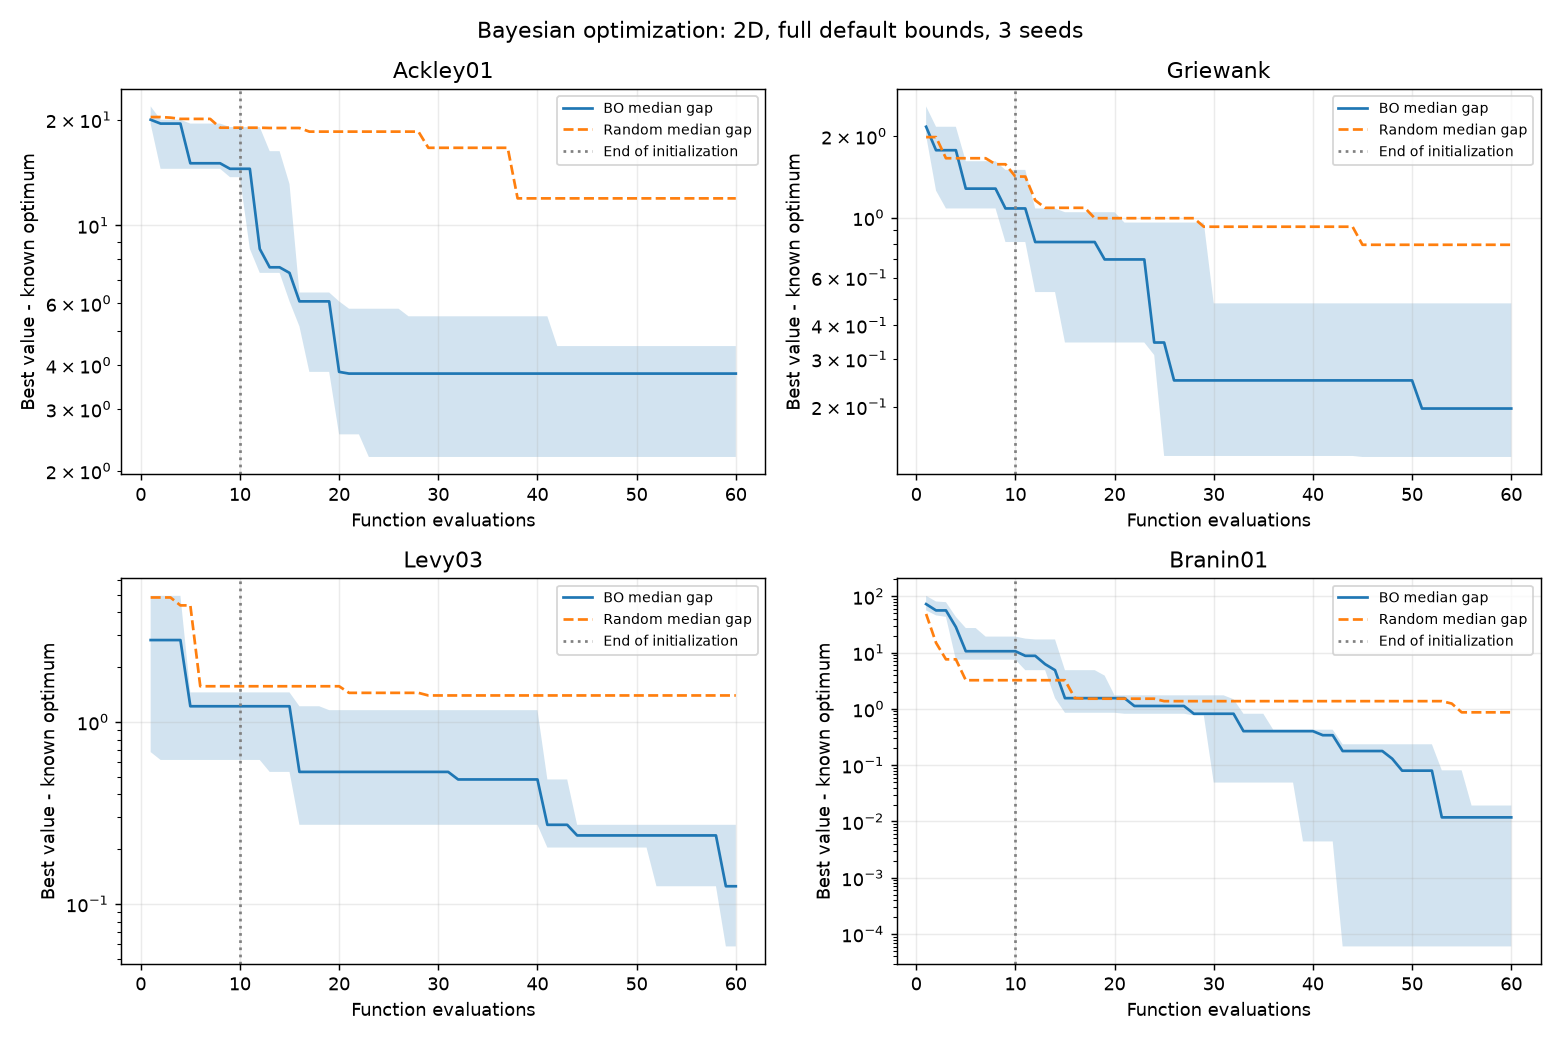

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, (case_name, _) in zip(axes.flat, BO_CASES):
    case_runs = [row for row in bo_results if row["function"] == case_name]
    known_value = case_runs[0]["known_optimum"]
    bo_gaps = np.array([row["best_history"] for row in case_runs]) - known_value
    random_gaps = np.array([row["random_history"] for row in case_runs]) - known_value
    counts = np.arange(1, BO_INIT_POINTS + BO_N_ITER + 1)
    axis.plot(counts, np.maximum(np.median(bo_gaps, axis=0), 1e-12), label="BO median gap")
    axis.fill_between(
        counts, np.maximum(np.min(bo_gaps, axis=0), 1e-12),
        np.maximum(np.max(bo_gaps, axis=0), 1e-12), alpha=0.2,
    )
    axis.plot(counts, np.maximum(np.median(random_gaps, axis=0), 1e-12), "--", label="Random median gap")
    axis.axvline(BO_INIT_POINTS, color="gray", linestyle=":", label="End of initialization")
    axis.set(title=case_name, xlabel="Function evaluations", ylabel="Best value - known optimum", yscale="log")
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
fig.suptitle("Bayesian optimization: 2D, full default bounds, 3 seeds")
fig.tight_layout()
plt.show()

曲线纵轴为“当前最好值 − 已知最优值”，使用对数尺度，越低越好。实线是三个种子的中位数，阴影是最好与最差运行的范围；虚线是相同评估预算的随机搜索中位数。随机搜索使用独立随机数生成器，并未强制与 BO 共用初始化样本，因此这是一个简要参考比较。

In [9]:
import csv
import json
from pathlib import Path

result_dir = Path("data")
result_dir.mkdir(exist_ok=True)
experiment = {
    "versions": {name: version(name) for name in ["bayesian-optimization", "opfunu", "numpy", "scipy", "scikit-learn"]},
    "settings": {"init_points": BO_INIT_POINTS, "n_iter": BO_N_ITER, "seeds": BO_SEEDS, "acquisition": "UCB", "kappa": 2.576, "input_scaling": "unit cube"},
    "summary": bo_summary, "runs": bo_results,
}
json_path = result_dir / "bayesian_optimization_results.json"
json_path.write_text(json.dumps(experiment, ensure_ascii=False, indent=2) + "\n")
csv_path = result_dir / "bayesian_optimization_results.csv"
fields = ["function", "ndim", "seed", "evaluations", "best_value", "known_optimum", "gap", "best_x", "random_best", "seconds"]
with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=fields, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(bo_results)
print("详细结果、参数及全部采样记录:", json_path)
print("每次运行的结果表:", csv_path)

详细结果、参数及全部采样记录: data/bayesian_optimization_results.json
每次运行的结果表: data/bayesian_optimization_results.csv


## 高维与复杂 CEC 函数实验

继续使用上面的 `run_bo_case`（已扩展为支持任意正整数维度和独立预算）。输入缩放、UCB 参数与前面的二维实验相同，使用函数默认的完整搜索范围。

| 测试 | 维度 | 难点 |
| --- | --- | --- |
| Ackley01 | 5 / 10 / 20 | 多峰，观察维度增加后的效果 |
| Griewank | 10 | 多峰、含变量间乘积项 |
| CEC F32014 | 10 | 平移、旋转的 Discus，各方向曲率差异很大 |
| CEC F92014 | 10 / 20 | 平移、旋转的 Rastrigin，多峰且变量耦合 |
| CEC F172014 | 10 | 平移、旋转、打乱变量后混合多个子函数 |

CEC 接口参考：[opfunu 官方文档](https://opfunu.readthedocs.io/en/stable/pages/cec_based.html)。具体维度支持和最优值以本地安装版本为准。

每组使用种子 `0, 1, 42`，每次 **120 次评估：20 次随机初始化 + 100 次贝叶斯迭代**，共 24 次运行、2880 次 BO 目标评估。随机搜索另用相同预算。CEC 的最优值包含偏置，因此比较 `最好值 − 已知最优值`；不同函数的数值尺度不同，不应直接用原始目标值大小判断谁更难。已知最优解只用于单独验证函数，不提供给优化器。

In [10]:
from opfunu.cec_based.cec2014 import F32014, F92014, F172014

HIGH_INIT_POINTS: int = 20
HIGH_N_ITER: int = 100
HIGH_SEEDS = [0, 1, 42]
HIGH_CASES: list[tuple[str, Callable[[], Benchmark]]] = [
    ("Ackley01_5D", lambda: Ackley01(ndim=5)),
    ("Ackley01_10D", lambda: Ackley01(ndim=10)),
    ("Ackley01_20D", lambda: Ackley01(ndim=20)),
    ("Griewank_10D", lambda: Griewank(ndim=10)),
    ("CEC_F3_10D", lambda: F32014(ndim=10)),
    ("CEC_F9_10D", lambda: F92014(ndim=10)),
    ("CEC_F9_20D", lambda: F92014(ndim=20)),
    ("CEC_F17_10D", lambda: F172014(ndim=10)),
]

# 在独立对象上验证基准最优值，不占用优化预算。
for high_name, high_factory in HIGH_CASES:
    reference_problem = high_factory()
    reference_optimum = reference_problem.f_global
    reference_x = reference_problem.x_global
    assert reference_optimum is not None and reference_x is not None
    assert np.isclose(reference_problem.evaluate(reference_x), reference_optimum, atol=1e-8)
    print(f"{high_name:<14} ndim={reference_problem.ndim}, optimum={reference_optimum}, bounds[0]={[reference_problem.lb[0], reference_problem.ub[0]]}")

Ackley01_5D    ndim=5, optimum=0.0, bounds[0]=[np.float64(-35.0), np.float64(35.0)]
Ackley01_10D   ndim=10, optimum=0.0, bounds[0]=[np.float64(-35.0), np.float64(35.0)]
Ackley01_20D   ndim=20, optimum=0.0, bounds[0]=[np.float64(-35.0), np.float64(35.0)]
Griewank_10D   ndim=10, optimum=0.0, bounds[0]=[np.float64(-100.0), np.float64(100.0)]
CEC_F3_10D     ndim=10, optimum=300.0, bounds[0]=[np.float64(-100.0), np.float64(100.0)]
CEC_F9_10D     ndim=10, optimum=900.0, bounds[0]=[np.float64(-100.0), np.float64(100.0)]
CEC_F9_20D     ndim=20, optimum=900.0, bounds[0]=[np.float64(-100.0), np.float64(100.0)]
CEC_F17_10D    ndim=10, optimum=1700.0, bounds[0]=[np.float64(-100.0), np.float64(100.0)]


In [11]:
high_results: list[dict] = []
for high_name, high_factory in HIGH_CASES:
    for high_seed in HIGH_SEEDS:
        high_result = run_bo_case(
            high_name, high_factory, high_seed,
            init_points=HIGH_INIT_POINTS, n_iter=HIGH_N_ITER,
        )
        high_results.append(high_result)
        print(
            f"{high_name:<14} seed={high_seed:2d} "
            f"best={high_result['best_value']:.9g} "
            f"gap={high_result['gap']:.6g} "
            f"random={high_result['random_best']:.6g} "
            f"time={high_result['seconds']:.1f}s",
            flush=True,
        )

Ackley01_5D    seed= 0 best=3.04886636 gap=3.04887 random=17.6934 time=6.7s
Ackley01_5D    seed= 1 best=18.1510281 gap=18.151 random=16.5593 time=2.8s
Ackley01_5D    seed=42 best=16.8905133 gap=16.8905 random=16.0921 time=7.2s
Ackley01_10D   seed= 0 best=5.02757482 gap=5.02757 random=17.8246 time=15.6s
Ackley01_10D   seed= 1 best=4.6314224 gap=4.63142 random=19.8674 time=17.8s
Ackley01_10D   seed=42 best=20.1432148 gap=20.1432 random=19.3152 time=2.3s
Ackley01_20D   seed= 0 best=10.0408516 gap=10.0409 random=19.7397 time=45.8s
Ackley01_20D   seed= 1 best=9.28023611 gap=9.28024 random=20.6484 time=69.1s
Ackley01_20D   seed=42 best=20.72684 gap=20.7268 random=20.1495 time=4.0s
Griewank_10D   seed= 0 best=1.02775058 gap=1.02775 random=2.36609 time=25.0s
Griewank_10D   seed= 1 best=0.973043781 gap=0.973044 random=4.10992 time=28.1s
Griewank_10D   seed=42 best=1.01185115 gap=1.01185 random=3.46707 time=25.8s
CEC_F3_10D     seed= 0 best=2435431.15 gap=2.43513e+06 random=153035 time=17.7s
CEC

In [12]:
high_summary: list[dict] = []
print("高维实验：每组 3 个种子，每次 120 次评估，越小越好")
print(f"{'Case':<15} {'Optimum':>12} {'BO best':>14} {'Best gap':>14} {'BO median':>14} {'Random median':>14} {'Init median':>14}")
for high_name, _ in HIGH_CASES:
    high_runs = [row for row in high_results if row["function"] == high_name]
    high_winner = min(high_runs, key=lambda row: row["best_value"])
    high_median = float(np.median([row["best_value"] for row in high_runs]))
    high_random_median = float(np.median([row["random_best"] for row in high_runs]))
    high_initial_median = float(np.median([row["best_history"][HIGH_INIT_POINTS - 1] for row in high_runs]))
    high_summary.append({
        "function": high_name, "ndim": high_winner["ndim"],
        "known_optimum": high_winner["known_optimum"],
        "best_value": high_winner["best_value"], "gap": high_winner["gap"],
        "median_value": high_median,
        "worst_value": max(row["best_value"] for row in high_runs),
        "random_median": high_random_median, "initial_median": high_initial_median,
        "best_seed": high_winner["seed"], "best_x": high_winner["best_x"],
    })
    print(f"{high_name:<15} {high_winner['known_optimum']:>12.6g} {high_winner['best_value']:>14.9g} {high_winner['gap']:>14.9g} {high_median:>14.9g} {high_random_median:>14.9g} {high_initial_median:>14.9g}")
    print(f"  最好解（seed={high_winner['seed']}）: {high_winner['best_x']}")

print("\nInit median 是 BO 前 20 次随机初始化结束时的最好值中位数，便于观察后续 100 次迭代带来的改进。")

高维实验：每组 3 个种子，每次 120 次评估，越小越好
Case                 Optimum        BO best       Best gap      BO median  Random median    Init median
Ackley01_5D                0     3.04886636     3.04886636     16.8905133     16.5592698     20.0493425
  最好解（seed=0）: [-0.061167347486382084, -0.512104457671704, 0.16595039434764658, -0.7669976871294466, 0.11680315907823768]
Ackley01_10D               0      4.6314224      4.6314224     5.02757482     19.3151619     20.5770902
  最好解（seed=1）: [0.48911430728662, 0.13885561299390048, -1.1096165908870645, 1.5811289740401762, -0.8262827488927726, 0.4619091533335151, 1.2450984525841093, 0.012799019389454713, 0.3079478084589553, -0.02417866590995743]
Ackley01_20D               0     9.28023611     9.28023611     10.0408516     20.1494887       20.72684
  最好解（seed=1）: [-3.6504240259312404, 3.1252376485057027, 0.77189503022624, -1.8432126728920082, 2.189267975072248, -1.5984252649306683, -2.5675893600355693, 4.066146309683248, -0.7174510016809137, 0.012901903893

cell_13:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


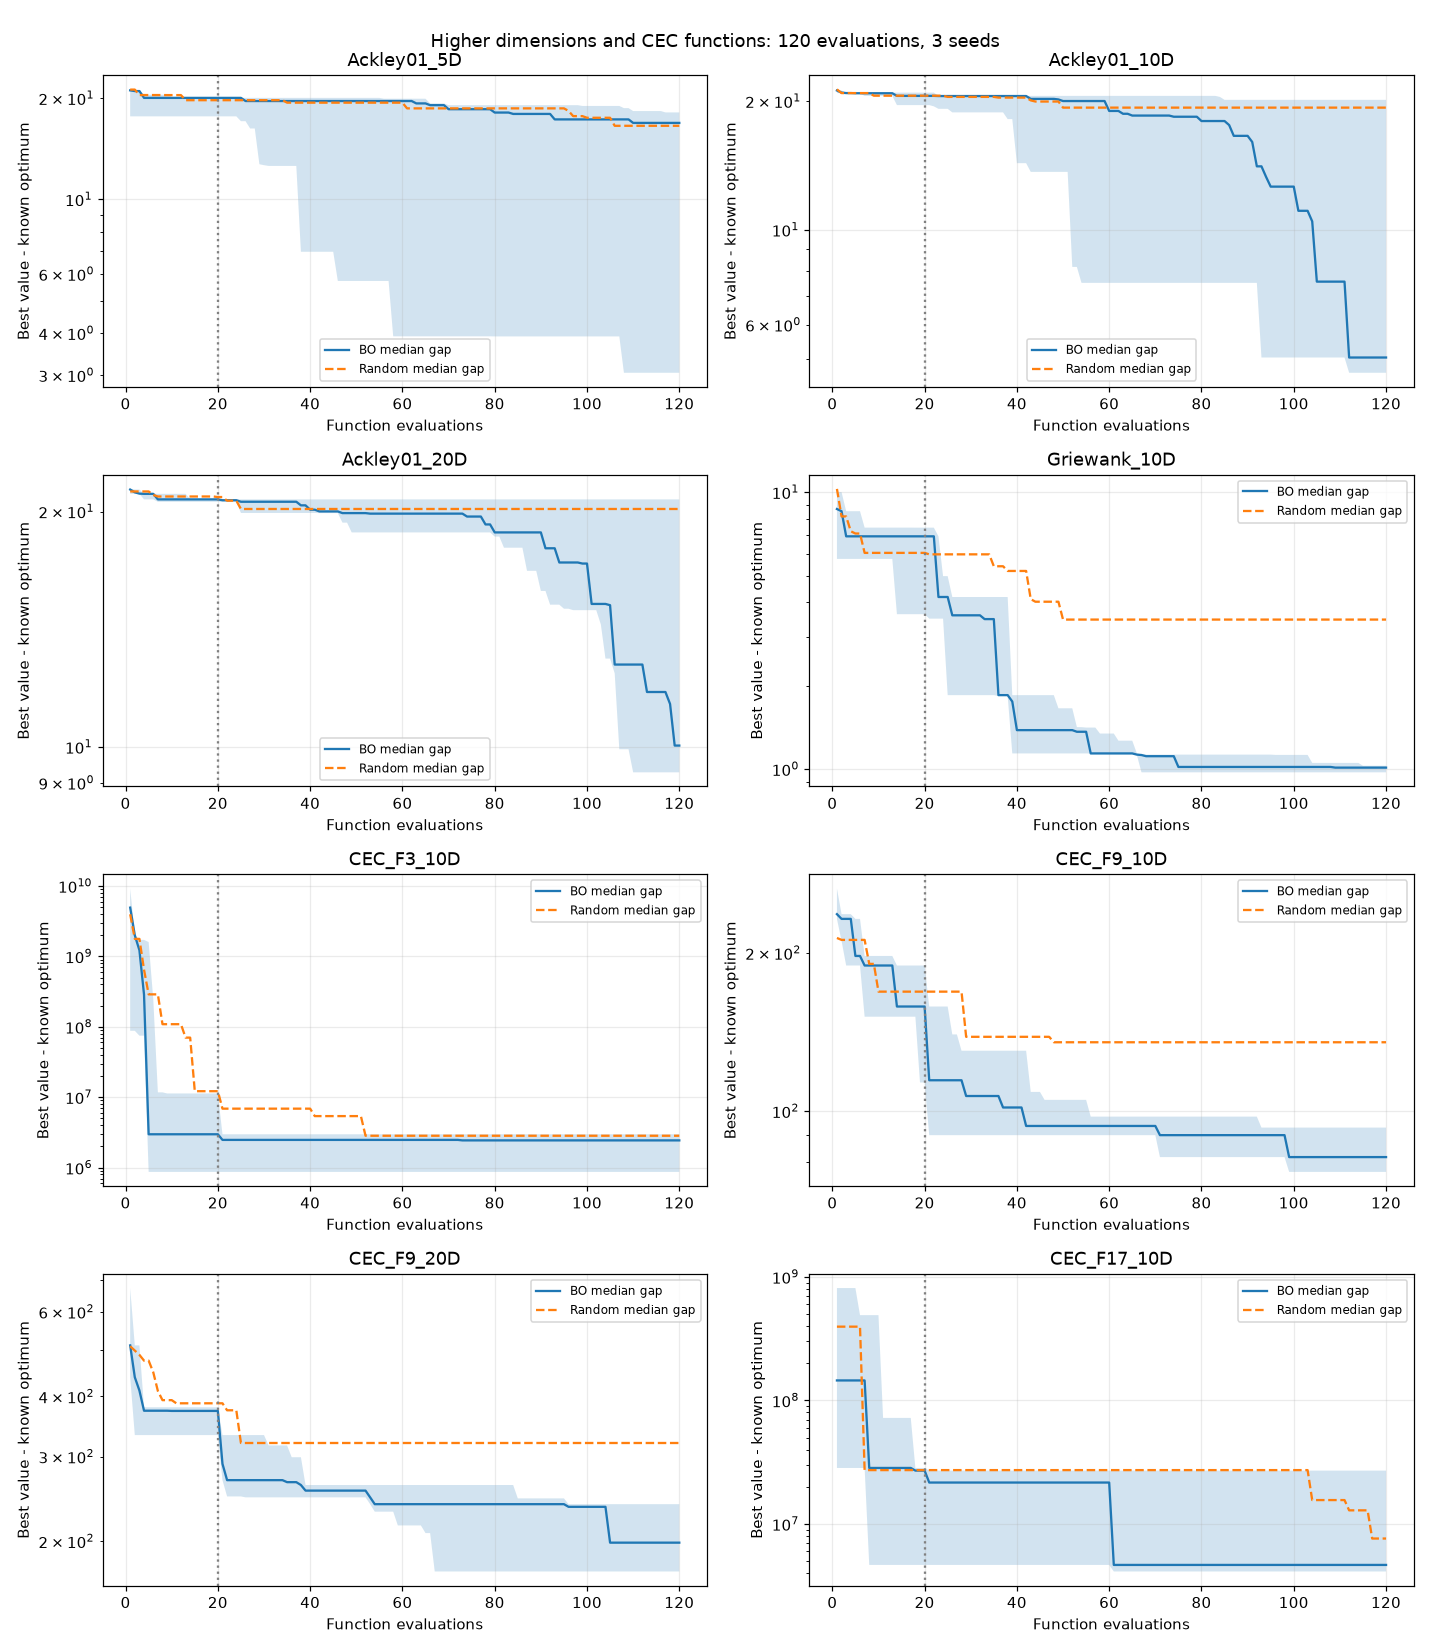

In [13]:
import matplotlib.pyplot as plt

high_fig, high_axes = plt.subplots(4, 2, figsize=(13, 15))
for high_axis, (high_name, _) in zip(high_axes.flat, HIGH_CASES):
    high_runs = [row for row in high_results if row["function"] == high_name]
    high_optimum = high_runs[0]["known_optimum"]
    high_bo_gaps = np.array([row["best_history"] for row in high_runs]) - high_optimum
    high_random_gaps = np.array([row["random_history"] for row in high_runs]) - high_optimum
    high_counts = np.arange(1, HIGH_INIT_POINTS + HIGH_N_ITER + 1)
    high_axis.plot(high_counts, np.maximum(np.median(high_bo_gaps, axis=0), 1e-12), label="BO median gap")
    high_axis.fill_between(
        high_counts, np.maximum(np.min(high_bo_gaps, axis=0), 1e-12),
        np.maximum(np.max(high_bo_gaps, axis=0), 1e-12), alpha=0.2,
    )
    high_axis.plot(high_counts, np.maximum(np.median(high_random_gaps, axis=0), 1e-12), "--", label="Random median gap")
    high_axis.axvline(HIGH_INIT_POINTS, color="gray", linestyle=":")
    high_axis.set(title=high_name, xlabel="Function evaluations", ylabel="Best value - known optimum", yscale="log")
    high_axis.grid(alpha=0.25)
    high_axis.legend(fontsize=8)
high_fig.suptitle("Higher dimensions and CEC functions: 120 evaluations, 3 seeds")
high_fig.tight_layout()
plt.show()

In [14]:
import csv
import json
from pathlib import Path

high_result_dir = Path("data")
high_result_dir.mkdir(exist_ok=True)
high_experiment = {
    "versions": {name: version(name) for name in ["bayesian-optimization", "opfunu", "numpy", "scipy", "scikit-learn"]},
    "settings": {"init_points": HIGH_INIT_POINTS, "n_iter": HIGH_N_ITER, "seeds": HIGH_SEEDS, "acquisition": "UCB", "kappa": 2.576, "input_scaling": "unit cube"},
    "summary": high_summary, "runs": high_results,
}
high_json_path = high_result_dir / "bayesian_optimization_highdim_results.json"
high_json_path.write_text(json.dumps(high_experiment, ensure_ascii=False, indent=2) + "\n")
high_csv_path = high_result_dir / "bayesian_optimization_highdim_results.csv"
high_fields = ["function", "ndim", "seed", "evaluations", "best_value", "known_optimum", "gap", "best_x", "random_best", "seconds"]
with high_csv_path.open("w", newline="", encoding="utf-8") as high_csv_file:
    high_writer = csv.DictWriter(high_csv_file, fieldnames=high_fields, extrasaction="ignore")
    high_writer.writeheader()
    high_writer.writerows(high_results)
print("高维实验完整记录:", high_json_path)
print("高维实验结果表:", high_csv_path)

高维实验完整记录: data/bayesian_optimization_highdim_results.json
高维实验结果表: data/bayesian_optimization_highdim_results.csv


### 本次高维实验的观察

- 在这 3 个种子、120 次评估的配置下，Ackley 的最好值由 5 维的 3.048866 增至 10 维的 4.631422、20 维的 9.280236，均未接近最优值 0。不过中位数并不随维度单调变化，说明种子差异也很大。
- 旋转 Rastrigin 的最好误差由 10 维的 76.617439 增至 20 维的 173.029368。这两组的 3 次运行均在初始化后继续改进。
- Discus 的最好值约 869581.046，最优值是 300；该最好运行的最好点就出现在随机初始化阶段。3 个种子中仅 1 个在后续 BO 迭代有改进。
- 混合函数 F17 的最好值约 4128860.2，最优值为 1700。3 个种子中也只有 1 个在初始化后继续改进，仍远离最优值。
- BO 的最终中位数在 8 组中有 7 组优于同预算随机搜索；5 维 Ackley 的中位数略差。单个种子可能明显更差，因此不能用最好的一次代替稳定性评价。

这些结果支持的结论是：当前 UCB + 高斯过程配置在部分高维函数上有改进，但 120 次评估不足以保证接近全局最优，对曲率差异大、旋转或混合函数的效果尤其有限。这里只测了 3 个种子，不能据此断言贝叶斯优化整体优于或劣于其他算法。后续可增加预算，比较核函数、采集策略，以及专门面向高维的优化方法。


## pymoo 遗传算法 GA：同预算比较与更长运行

使用 [pymoo 官方 GA](https://pymoo.org/algorithms/soo/ga.html)，继续测试上述 8 组高维函数，种子仍为 `0, 1, 42`，保留 opfunu 原始搜索边界。pymoo 默认执行最小化，不需要对目标取负号。

- 将 opfunu 包装成 pymoo 的单目标 `Problem`，每批种群逐个调用 `evaluate`。
- 种群与每代子代均为 **40** 个；使用随机实数初始化、默认锦标赛选择、SBX 交叉、多项式变异和去重。
- 每次运行 **6000 次目标评估**，记录 **120 / 1200 / 6000** 次评估时的最好值。120 次仅相当于初始种群和两轮子代，适合核对同预算结果，不能代表 GA 充分迭代后的效果。
- 6000 次是此前 BO 预算的 **50 倍**，大预算结果只用于观察 GA 的收敛潜力，不作为同预算胜负比较。
- BO 对比读取此前保存的高维实验 JSON，不重复运行耗时的 BO。GA 与 BO 使用相同种子编号，但不共用初始化样本。
- 已知最优解不进入 GA 种群，仅用已知最优值计算误差。运行后核对实际评估次数、边界和返回结果。

这里固定同一套 GA 参数，不按每个函数单独调参。默认算子参数和依赖版本会保存到结果 JSON。

In [15]:
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination
import json
from pathlib import Path

GA_POP_SIZE: int = 40
GA_MAX_EVALS: int = 6000
GA_CHECKPOINTS = [120, 1200, 6000]
GA_SEEDS = [0, 1, 42]
print("pymoo 版本:", version("pymoo"))


class OpfunuGAProblem(Problem):
    """将 opfunu 函数接入 pymoo，并记录实际目标求值。"""

    def __init__(self, benchmark: Benchmark):
        problem_dimension = benchmark.ndim
        assert isinstance(problem_dimension, int) and problem_dimension > 0
        self.benchmark = benchmark
        self.evaluated_values: list[float] = []
        self.evaluated_points: list[list[float]] = []
        super().__init__(
            n_var=problem_dimension, n_obj=1,
            xl=np.asarray(benchmark.lb, dtype=float),
            xu=np.asarray(benchmark.ub, dtype=float),
        )

    def _evaluate(self, X, out, *args, **kwargs):
        candidates = np.asarray(X, dtype=float)
        values = []
        for candidate in candidates:
            value = float(self.benchmark.evaluate(candidate))
            values.append(value)
            self.evaluated_values.append(value)
            self.evaluated_points.append(candidate.tolist())
        out["F"] = np.asarray(values, dtype=float).reshape(-1, 1)


def run_ga_case(name: str, factory: Callable[[], Benchmark], seed: int) -> dict:
    benchmark = factory()
    optimum = benchmark.f_global
    assert optimum is not None
    optimum_value = float(optimum)
    problem = OpfunuGAProblem(benchmark)
    ga_algorithm = GA(
        pop_size=GA_POP_SIZE, n_offsprings=GA_POP_SIZE,
        eliminate_duplicates=True,
    )
    start = perf_counter()
    ga_result = minimize(
        problem, ga_algorithm, get_termination("n_eval", GA_MAX_EVALS),
        seed=seed, verbose=False,
    )
    elapsed = perf_counter() - start
    assert ga_result.algorithm is not None
    actual_evaluations = int(ga_result.algorithm.evaluator.n_eval)
    assert actual_evaluations == GA_MAX_EVALS
    assert len(problem.evaluated_values) == actual_evaluations
    assert benchmark.n_fe == actual_evaluations
    assert ga_result.F is not None and ga_result.X is not None
    final_value = float(np.asarray(ga_result.F).ravel()[0])
    final_x = np.asarray(ga_result.X, dtype=float).ravel()
    assert np.all((final_x >= benchmark.lb) & (final_x <= benchmark.ub))
    # 使用独立基准对象复核，避免增加本次算法的评估次数。
    checker = factory()
    assert np.isclose(checker.evaluate(final_x), final_value, rtol=1e-10, atol=1e-10)

    values = np.asarray(problem.evaluated_values)
    best_history = np.minimum.accumulate(values)
    checkpoint_rows: list[dict] = []
    for checkpoint in GA_CHECKPOINTS:
        index = int(np.argmin(values[:checkpoint]))
        checkpoint_value = float(values[index])
        checkpoint_rows.append({
            "function": name, "ndim": int(problem.n_var), "seed": seed,
            "evaluations": checkpoint, "best_value": checkpoint_value,
            "known_optimum": optimum_value, "gap": checkpoint_value - optimum_value,
            "best_x": problem.evaluated_points[index],
        })
    assert np.isclose(final_value, checkpoint_rows[-1]["best_value"])
    # GA 每一代是一批候选解，只在完整代末记录收敛曲线。
    generation_counts = np.arange(GA_POP_SIZE, actual_evaluations + 1, GA_POP_SIZE)
    return {
        "function": name, "ndim": int(problem.n_var), "seed": seed,
        "evaluations": actual_evaluations, "seconds": elapsed,
        "known_optimum": optimum_value, "best_value": final_value,
        "gap": final_value - optimum_value, "best_x": final_x.tolist(),
        "checkpoints": checkpoint_rows,
        "history_evaluations": generation_counts.tolist(),
        "best_history": best_history[generation_counts - 1].tolist(),
    }


bo_comparison_path = Path("data/bayesian_optimization_highdim_results.json")
bo_comparison = json.loads(bo_comparison_path.read_text())
assert bo_comparison["settings"]["init_points"] + bo_comparison["settings"]["n_iter"] == 120
assert bo_comparison["settings"]["seeds"] == GA_SEEDS
print("BO 比较数据:", bo_comparison_path)

pymoo 版本: 0.6.2
BO 比较数据: data/bayesian_optimization_highdim_results.json


In [16]:
ga_results: list[dict] = []
for ga_name, ga_factory in HIGH_CASES:
    for ga_seed in GA_SEEDS:
        ga_run = run_ga_case(ga_name, ga_factory, ga_seed)
        ga_results.append(ga_run)
        checkpoint_text = ", ".join(
            f"{row['evaluations']}次={row['best_value']:.9g}"
            for row in ga_run["checkpoints"]
        )
        print(f"{ga_name:<14} seed={ga_seed:2d} {checkpoint_text}, time={ga_run['seconds']:.2f}s", flush=True)

Ackley01_5D    seed= 0 120次=16.7724448, 1200次=1.16846441, 6000次=0.0268286397, time=0.19s
Ackley01_5D    seed= 1 120次=19.0313456, 1200次=2.54594298, 6000次=0.0257303046, time=0.19s
Ackley01_5D    seed=42 120次=18.5274028, 1200次=0.481378981, 6000次=0.0377744572, time=0.18s
Ackley01_10D   seed= 0 120次=19.3368846, 1200次=3.67959455, 6000次=0.0919060008, time=0.15s
Ackley01_10D   seed= 1 120次=18.9499177, 1200次=2.96266068, 6000次=0.107676776, time=0.15s
Ackley01_10D   seed=42 120次=18.509796, 1200次=4.88155805, 6000次=0.143019882, time=0.20s
Ackley01_20D   seed= 0 120次=19.6589942, 1200次=10.5463994, 6000次=0.528416176, time=0.20s
Ackley01_20D   seed= 1 120次=20.5702943, 1200次=10.6099508, 6000次=0.562579245, time=0.16s
Ackley01_20D   seed=42 120次=20.0111236, 1200次=10.491538, 6000次=0.380214003, time=0.16s
Griewank_10D   seed= 0 120次=3.76681637, 1200次=0.806277512, 6000次=0.0464008253, time=0.15s
Griewank_10D   seed= 1 120次=3.85942317, 1200次=0.749354085, 6000次=0.094533581, time=0.15s
Griewank_10D   seed=42 120

In [17]:
ga_summary: list[dict] = []
print("三次运行的中位数对比（目标越小越好）")
print(f"{'Case':<15} {'BO@120':>14} {'GA@120':>14} {'GA@1200':>14} {'GA@6000':>14} {'GA best@6000':>16} {'Best gap':>14}")
for ga_name, _ in HIGH_CASES:
    ga_case_runs = [row for row in ga_results if row["function"] == ga_name]
    bo_case_runs = [row for row in bo_comparison["runs"] if row["function"] == ga_name]
    assert len(ga_case_runs) == len(bo_case_runs) == len(GA_SEEDS)
    assert all(row["evaluations"] == 120 for row in bo_case_runs)
    bo_median = float(np.median([row["best_value"] for row in bo_case_runs]))
    ga_medians = {
        checkpoint: float(np.median([
            next(item["best_value"] for item in row["checkpoints"] if item["evaluations"] == checkpoint)
            for row in ga_case_runs
        ]))
        for checkpoint in GA_CHECKPOINTS
    }
    ga_winner = min(ga_case_runs, key=lambda row: row["best_value"])
    ga_summary.append({
        "function": ga_name, "ndim": ga_winner["ndim"],
        "known_optimum": ga_winner["known_optimum"],
        "bo_median_120": bo_median,
        "ga_median_120": ga_medians[120], "ga_median_1200": ga_medians[1200],
        "ga_median_6000": ga_medians[6000], "ga_best_6000": ga_winner["best_value"],
        "ga_best_gap_6000": ga_winner["gap"], "ga_best_seed": ga_winner["seed"],
        "ga_best_x": ga_winner["best_x"],
    })
    print(f"{ga_name:<15} {bo_median:>14.9g} {ga_medians[120]:>14.9g} {ga_medians[1200]:>14.9g} {ga_medians[6000]:>14.9g} {ga_winner['best_value']:>16.9g} {ga_winner['gap']:>14.9g}")

ga_same_budget_wins = sum(row["ga_median_120"] < row["bo_median_120"] for row in ga_summary)
print(f"\n同预算 120 次时，GA 中位数更好的组数: {ga_same_budget_wins}/{len(ga_summary)}")
print("6000 次 GA 与 120 次 BO 的预算不同，不能据此判定算法优劣。")

三次运行的中位数对比（目标越小越好）
Case                    BO@120         GA@120        GA@1200        GA@6000     GA best@6000       Best gap
Ackley01_5D         16.8905133     18.5274028     1.16846441   0.0268286397     0.0257303046   0.0257303046
Ackley01_10D        5.02757482     18.9499177     3.67959455    0.107676776     0.0919060008   0.0919060008
Ackley01_20D        10.0408516     20.0111236     10.5463994    0.528416176      0.380214003    0.380214003
Griewank_10D        1.01185115     3.76681637    0.749354085   0.0464008253     0.0251138795   0.0251138795
CEC_F3_10D          2435431.15     238495.264     21620.4845     13357.9607       1380.44762     1080.44762
CEC_F9_10D          981.752069      1017.9377     930.176704     920.058056        917.94362     17.9436203
CEC_F9_20D          1098.62284     1183.98916     956.355948      924.09483       915.300731      15.300731
CEC_F17_10D         4664529.55     1625219.03     23682.1137      13792.909       12004.9733     10304.9733

同预算 120 

cell_18:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


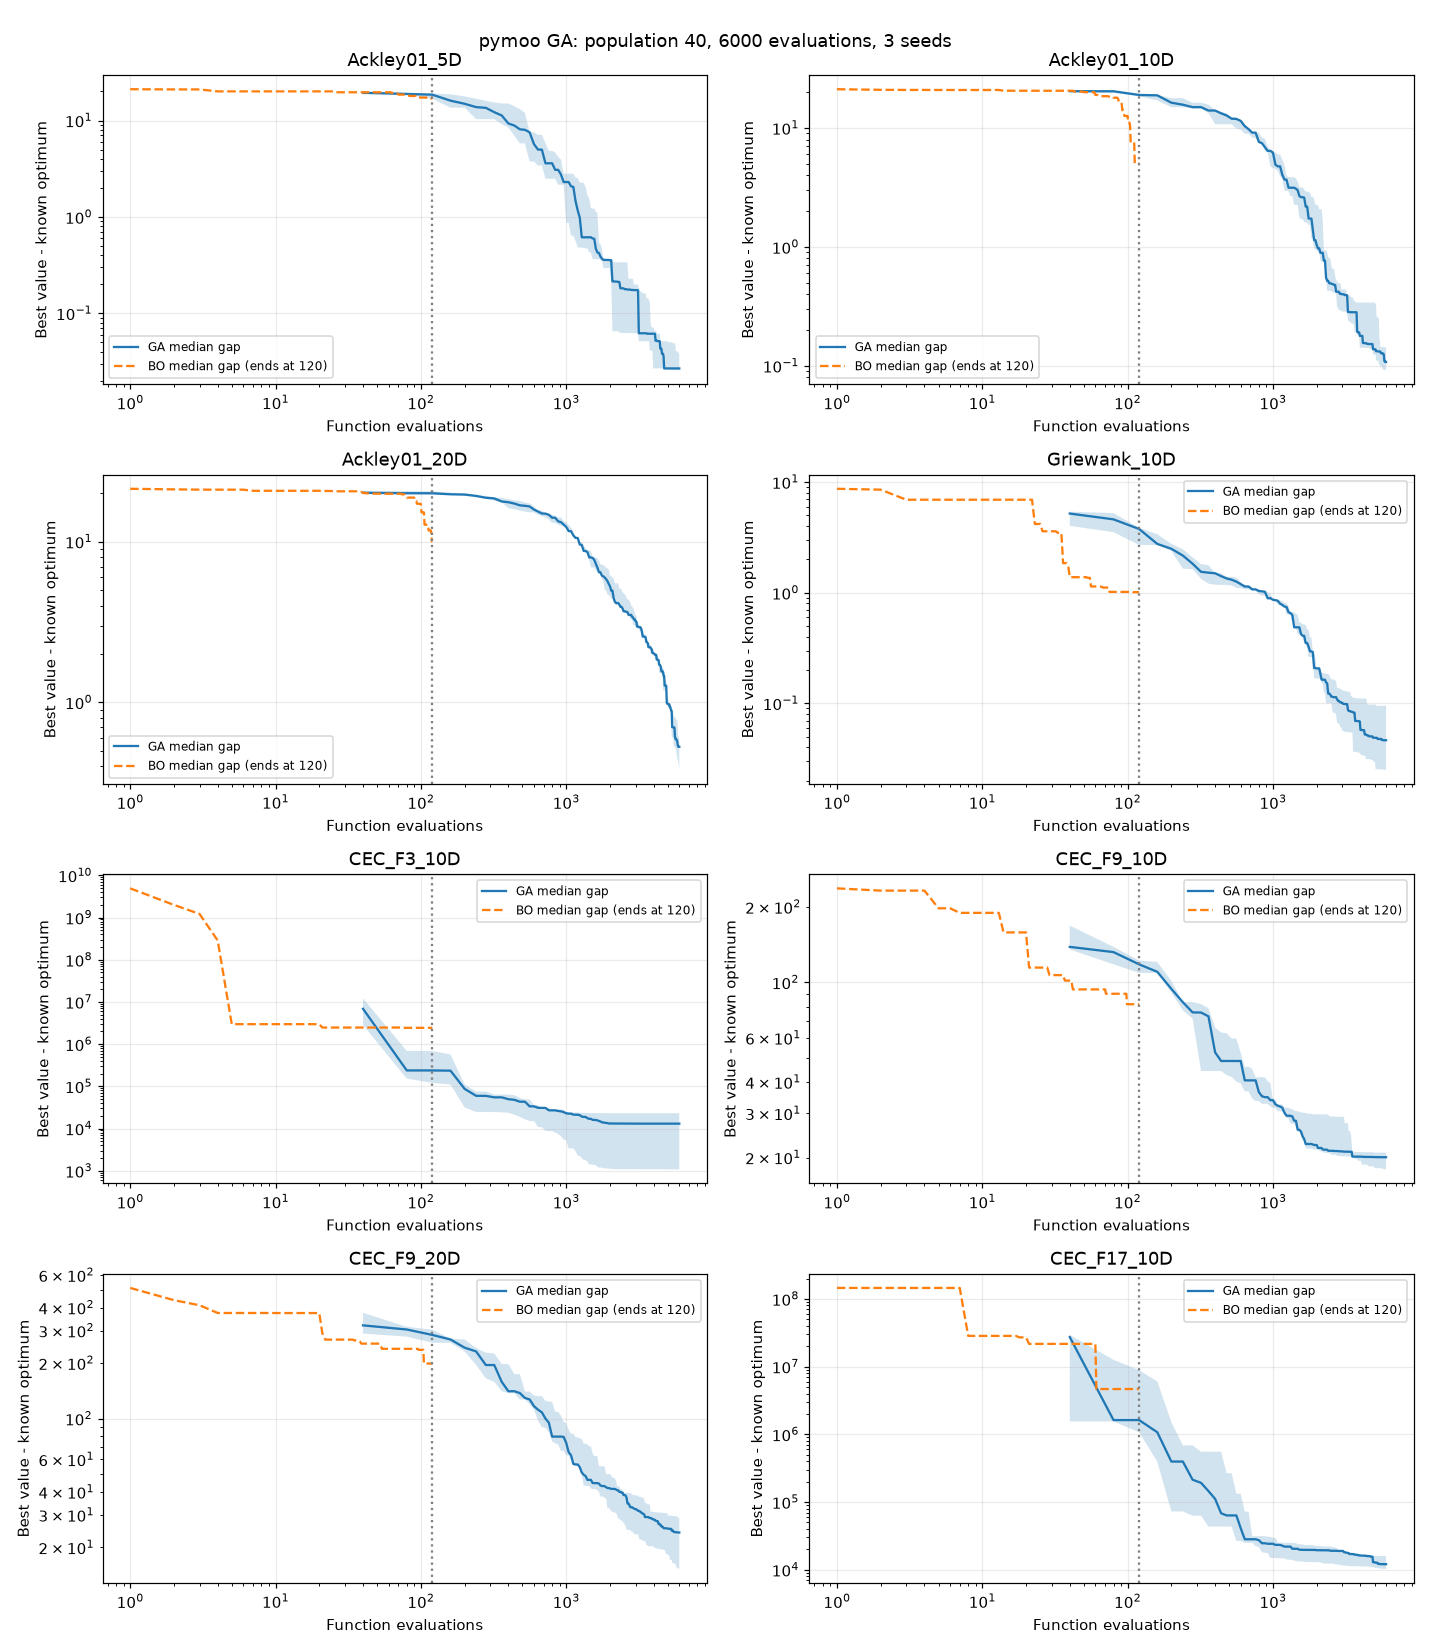

In [18]:
import matplotlib.pyplot as plt

ga_fig, ga_axes = plt.subplots(4, 2, figsize=(13, 15))
for ga_axis, (ga_name, _) in zip(ga_axes.flat, HIGH_CASES):
    ga_case_runs = [row for row in ga_results if row["function"] == ga_name]
    bo_case_runs = [row for row in bo_comparison["runs"] if row["function"] == ga_name]
    ga_known_value = ga_case_runs[0]["known_optimum"]
    ga_gap_histories = np.asarray([row["best_history"] for row in ga_case_runs]) - ga_known_value
    ga_eval_counts = np.asarray(ga_case_runs[0]["history_evaluations"])
    ga_axis.plot(ga_eval_counts, np.maximum(np.median(ga_gap_histories, axis=0), 1e-12), label="GA median gap")
    ga_axis.fill_between(
        ga_eval_counts, np.maximum(np.min(ga_gap_histories, axis=0), 1e-12),
        np.maximum(np.max(ga_gap_histories, axis=0), 1e-12), alpha=0.2,
    )
    bo_gap_histories = np.asarray([row["best_history"] for row in bo_case_runs]) - ga_known_value
    ga_axis.plot(
        np.arange(1, 121), np.maximum(np.median(bo_gap_histories, axis=0), 1e-12),
        "--", label="BO median gap (ends at 120)",
    )
    ga_axis.axvline(120, color="gray", linestyle=":")
    ga_axis.set(title=ga_name, xlabel="Function evaluations", ylabel="Best value - known optimum", xscale="log", yscale="log")
    ga_axis.grid(alpha=0.25)
    ga_axis.legend(fontsize=8)
ga_fig.suptitle("pymoo GA: population 40, 6000 evaluations, 3 seeds")
ga_fig.tight_layout()
plt.show()

In [19]:
import csv
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

def ga_scalar_parameter(value: object) -> float:
    # pymoo 参数容器的 value 静态类型很宽；验证后转换为可保存的标量。
    assert isinstance(value, (int, float, np.integer, np.floating))
    return float(value)


# 读取实际默认算子值，而不是凭文档假定参数。
ga_default_algorithm = GA(pop_size=GA_POP_SIZE, n_offsprings=GA_POP_SIZE)
ga_crossover = ga_default_algorithm.mating.crossover
ga_mutation = ga_default_algorithm.mating.mutation
assert isinstance(ga_crossover, SBX) and isinstance(ga_mutation, PM)
ga_experiment = {
    "versions": {name: version(name) for name in ["pymoo", "opfunu", "numpy", "scipy"]},
    "settings": {
        "pop_size": GA_POP_SIZE, "n_offsprings": GA_POP_SIZE,
        "max_evaluations": GA_MAX_EVALS, "checkpoints": GA_CHECKPOINTS,
        "seeds": GA_SEEDS, "eliminate_duplicates": True,
        "crossover": "SBX", "crossover_probability": ga_scalar_parameter(ga_crossover.prob.value),
        "crossover_eta": ga_scalar_parameter(ga_crossover.eta.value),
        "mutation": "PM", "mutation_probability": ga_scalar_parameter(ga_mutation.prob.value),
        "mutation_eta": ga_scalar_parameter(ga_mutation.eta.value),
        "mutation_probability_per_variable": "pymoo default: min(0.5, 1 / ndim)",
        "bounds": "opfunu full default bounds", "objective": "minimize",
        "bo_comparison_file": str(bo_comparison_path),
    },
    "summary": ga_summary, "runs": ga_results,
}
ga_result_dir = Path("data")
ga_result_dir.mkdir(exist_ok=True)
ga_json_path = ga_result_dir / "pymoo_ga_results.json"
ga_json_path.write_text(json.dumps(ga_experiment, ensure_ascii=False, indent=2) + "\n")
ga_csv_path = ga_result_dir / "pymoo_ga_results.csv"
ga_fields = ["function", "ndim", "seed", "evaluations", "best_value", "known_optimum", "gap", "best_x"]
with ga_csv_path.open("w", newline="", encoding="utf-8") as ga_csv_file:
    ga_writer = csv.DictWriter(ga_csv_file, fieldnames=ga_fields)
    ga_writer.writeheader()
    for ga_run in ga_results:
        ga_writer.writerows(ga_run["checkpoints"])
print("GA 参数与完整结果:", ga_json_path)
print("120 / 1200 / 6000 次评估结果表:", ga_csv_path)

GA 参数与完整结果: data/pymoo_ga_results.json
120 / 1200 / 6000 次评估结果表: data/pymoo_ga_results.csv


### GA 实验结果解读

- 6000 次评估时，GA 最好的目标值为：Ackley 5D **0.025730**、10D **0.091906**、20D **0.380214**，Griewank 10D **0.025114**。
- CEC Discus 10D 的最好值为 **1380.44762**（最优值 300）；旋转 Rastrigin 10D 为 **917.94362**、20D 为 **915.300731**（最优值均为 900）；混合函数 F17 10D 为 **12004.9733**（最优值 1700）。仍未达到全局最优。
- 相同 120 次预算下，按三个种子的中位数，GA 仅在 **Discus 和混合函数 F17** 两组优于 BO。120 次对种群 40 的 GA 只够初始种群及两轮子代。
- 从 120 增加到 1200、6000 次时，GA 在各组都有改进。6000 次的最好值均小于之前 BO 的最好值，但 GA 使用了 50 倍评估预算，因此这不能证明 GA 的采样效率更高。
- 本次运行中 GA 的计算时间很短，因为这些基准函数求值便宜；真实黑盒若单次评估耗时很长，更多评估会直接增加总成本。

三个种子只是初步实验。结果图中的阴影展示种子间范围；完整解向量、默认算子参数和各预算的结果见保存的 JSON / CSV。


## 公平比较：相同 120 次评估，且共用初始样本

主要比较应固定函数、维度、搜索范围和目标评估次数。这里以此前保存的 BO 实验为基准，每次 **120 次评估**，种子 `0, 1, 42`，对 8 组高维函数重新独立运行 GA。

为了控制初始样本的影响，GA 使用 BO 每次运行的 **前 20 个随机初始点**作为初始种群（还原到原始坐标），种群与每代子代均为 20。GA 重新对这 20 个点求值，计入自己的预算，接着进行 5 轮子代求值，总计 `20 + 5 × 20 = 120`。BO 为 `20 + 100 = 120`。GA 使用相同的默认 SBX、PM 算子。

这次 GA 的种群由前一节的 40 改为 20，目的是共用 BO 的全部初始点；前一节的 GA 结果不混入本次比较。共用的点全为随机初始化点，没有使用 BO 后续建议点或已知最优解。

复用 BO 保存的完整采样记录，并核对预算、种子、维度和边界；GA 在 120 次独立终止，核对实际评估次数及前 20 次目标值是否与 BO 一致。主要比较三个种子的**中位数与误差**，同时保留最好、最差值和各次运行。仅 3 个种子是初步实验，结论只适用于这个较小预算和当前配置。

In [20]:
EQUAL_BUDGET: int = 120
EQUAL_POP_SIZE: int = 20
EQUAL_SEEDS = [0, 1, 42]
equal_bo_data = json.loads(Path("data/bayesian_optimization_highdim_results.json").read_text())
assert equal_bo_data["settings"]["init_points"] == EQUAL_POP_SIZE
assert equal_bo_data["settings"]["init_points"] + equal_bo_data["settings"]["n_iter"] == EQUAL_BUDGET
assert equal_bo_data["settings"]["seeds"] == EQUAL_SEEDS


def run_equal_ga(name: str, factory: Callable[[], Benchmark], seed: int) -> dict:
    bo_runs = [row for row in equal_bo_data["runs"] if row["function"] == name and row["seed"] == seed]
    assert len(bo_runs) == 1
    bo_run = bo_runs[0]
    assert bo_run["evaluations"] == len(bo_run["observations"]) == EQUAL_BUDGET
    benchmark = factory()
    dimension = benchmark.ndim
    assert isinstance(dimension, int) and dimension == bo_run["ndim"]
    lower = np.asarray(benchmark.lb, dtype=float)
    upper = np.asarray(benchmark.ub, dtype=float)
    assert np.allclose(np.column_stack((lower, upper)), bo_run["bounds"])
    parameter_names = [f"x{i}" for i in range(dimension)]
    bo_initial_records = bo_run["observations"][:EQUAL_POP_SIZE]
    unit_initial = np.asarray([
        [row["params"][key] for key in parameter_names]
        for row in bo_initial_records
    ], dtype=float)
    shared_initial = lower + unit_initial * (upper - lower)
    bo_initial_values = np.asarray([-float(row["target"]) for row in bo_initial_records])
    problem = OpfunuGAProblem(benchmark)
    equal_algorithm = GA(
        pop_size=EQUAL_POP_SIZE, n_offsprings=EQUAL_POP_SIZE,
        sampling=shared_initial, eliminate_duplicates=True,
    )
    start = perf_counter()
    result = minimize(
        problem, equal_algorithm, get_termination("n_eval", EQUAL_BUDGET),
        seed=seed, verbose=False,
    )
    elapsed = perf_counter() - start
    assert result.algorithm is not None and result.X is not None and result.F is not None
    evaluations = int(result.algorithm.evaluator.n_eval)
    assert evaluations == benchmark.n_fe == len(problem.evaluated_values) == EQUAL_BUDGET
    values = np.asarray(problem.evaluated_values)
    assert np.allclose(values[:EQUAL_POP_SIZE], bo_initial_values, rtol=1e-10, atol=1e-10)
    assert np.allclose(np.asarray(problem.evaluated_points[:EQUAL_POP_SIZE]), shared_initial)
    optimum = benchmark.f_global
    assert optimum is not None and np.isclose(optimum, bo_run["known_optimum"])
    best_value = float(np.asarray(result.F).ravel()[0])
    best_x = np.asarray(result.X, dtype=float).ravel()
    assert np.isclose(best_value, np.min(values))
    assert np.all((best_x >= lower) & (best_x <= upper))
    checker = factory()
    assert np.isclose(checker.evaluate(best_x), best_value, rtol=1e-10, atol=1e-10)
    return {
        "function": name, "ndim": dimension, "seed": seed,
        "evaluations": evaluations, "known_optimum": float(optimum),
        "bo_best_value": bo_run["best_value"], "ga_best_value": best_value,
        "bo_gap": bo_run["gap"], "ga_gap": best_value - float(optimum),
        "bo_best_x": bo_run["best_x"], "ga_best_x": best_x.tolist(),
        "shared_initial_best": float(np.min(bo_initial_values)),
        "shared_initial_points": shared_initial.tolist(),
        "bo_seconds": bo_run["seconds"], "ga_seconds": elapsed,
        "bo_best_history": bo_run["best_history"],
        "ga_best_history": np.minimum.accumulate(values).tolist(),
        "ga_observed_values": values.tolist(),
    }

In [21]:
equal_runs: list[dict] = []
for equal_name, equal_factory in HIGH_CASES:
    for equal_seed in EQUAL_SEEDS:
        equal_run = run_equal_ga(equal_name, equal_factory, equal_seed)
        equal_runs.append(equal_run)
        print(
            f"{equal_name:<14} seed={equal_seed:2d} "
            f"BO={equal_run['bo_best_value']:.9g}, GA={equal_run['ga_best_value']:.9g}, "
            f"shared_init={equal_run['shared_initial_best']:.9g}",
            flush=True,
        )

Ackley01_5D    seed= 0 BO=3.04886636, GA=14.8697588, shared_init=17.66775
Ackley01_5D    seed= 1 BO=18.1510281, GA=15.1963652, shared_init=20.0493425
Ackley01_5D    seed=42 BO=16.8905133, GA=10.9583976, shared_init=20.0650171
Ackley01_10D   seed= 0 BO=5.02757482, GA=15.9317101, shared_init=19.580833
Ackley01_10D   seed= 1 BO=4.6314224, GA=19.2320505, shared_init=20.9410387
Ackley01_10D   seed=42 BO=20.1432148, GA=19.6576849, shared_init=20.5770902
Ackley01_20D   seed= 0 BO=10.0408516, GA=20.0062208, shared_init=20.5827032
Ackley01_20D   seed= 1 BO=9.28023611, GA=19.6704781, shared_init=20.7565234
Ackley01_20D   seed=42 BO=20.72684, GA=20.3180936, shared_init=20.72684
Griewank_10D   seed= 0 BO=1.02775058, GA=1.75780032, shared_init=3.62560988
Griewank_10D   seed= 1 BO=0.973043781, GA=2.52355749, shared_init=7.44774425
Griewank_10D   seed=42 BO=1.01185115, GA=2.96012126, shared_init=6.92920228
CEC_F3_10D     seed= 0 BO=2435431.15, GA=80567.6994, shared_init=11298042.3
CEC_F3_10D     seed

In [22]:
equal_summary: list[dict] = []
print("同初始样本、同 120 次评估：三个种子的中位数，越小越好")
print(f"{'Case':<15} {'BO median':>14} {'GA median':>14} {'BO gap median':>15} {'GA gap median':>15} {'Winner':>8}")
for equal_name, _ in HIGH_CASES:
    case_equal_runs = [row for row in equal_runs if row["function"] == equal_name]
    bo_equal_median = float(np.median([row["bo_best_value"] for row in case_equal_runs]))
    ga_equal_median = float(np.median([row["ga_best_value"] for row in case_equal_runs]))
    bo_equal_gap = float(np.median([row["bo_gap"] for row in case_equal_runs]))
    ga_equal_gap = float(np.median([row["ga_gap"] for row in case_equal_runs]))
    equal_winner = "BO" if bo_equal_median < ga_equal_median else "GA" if ga_equal_median < bo_equal_median else "Tie"
    equal_summary.append({
        "function": equal_name, "ndim": case_equal_runs[0]["ndim"],
        "evaluations": EQUAL_BUDGET, "known_optimum": case_equal_runs[0]["known_optimum"],
        "bo_median": bo_equal_median, "ga_median": ga_equal_median,
        "bo_gap_median": bo_equal_gap, "ga_gap_median": ga_equal_gap,
        "bo_best": min(row["bo_best_value"] for row in case_equal_runs),
        "ga_best": min(row["ga_best_value"] for row in case_equal_runs),
        "bo_worst": max(row["bo_best_value"] for row in case_equal_runs),
        "ga_worst": max(row["ga_best_value"] for row in case_equal_runs),
        "winner_by_median": equal_winner,
        "ga_paired_wins": sum(row["ga_best_value"] < row["bo_best_value"] for row in case_equal_runs),
    })
    print(f"{equal_name:<15} {bo_equal_median:>14.9g} {ga_equal_median:>14.9g} {bo_equal_gap:>15.9g} {ga_equal_gap:>15.9g} {equal_winner:>8}")
print("\nBO 中位数更好的组数:", sum(row["winner_by_median"] == "BO" for row in equal_summary))
print("GA 中位数更好的组数:", sum(row["winner_by_median"] == "GA" for row in equal_summary))
print("只比较 120 次，不能用前一节 GA 6000 次的结果判定同预算胜负。")

同初始样本、同 120 次评估：三个种子的中位数，越小越好
Case                 BO median      GA median   BO gap median   GA gap median   Winner
Ackley01_5D         16.8905133     14.8697588      16.8905133      14.8697588       GA
Ackley01_10D        5.02757482     19.2320505      5.02757482      19.2320505       BO
Ackley01_20D        10.0408516     20.0062208      10.0408516      20.0062208       BO
Griewank_10D        1.01185115     2.52355749      1.01185115      2.52355749       BO
CEC_F3_10D          2435431.15     80567.6994      2435131.15      80267.6994       GA
CEC_F9_10D          981.752069     978.275289      81.7520689      78.2752892       GA
CEC_F9_20D          1098.62284     1149.88497      198.622839       249.88497       BO
CEC_F17_10D         4664529.55     3031527.69      4662829.55      3029827.69       GA

BO 中位数更好的组数: 4
GA 中位数更好的组数: 4
只比较 120 次，不能用前一节 GA 6000 次的结果判定同预算胜负。


cell_23:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


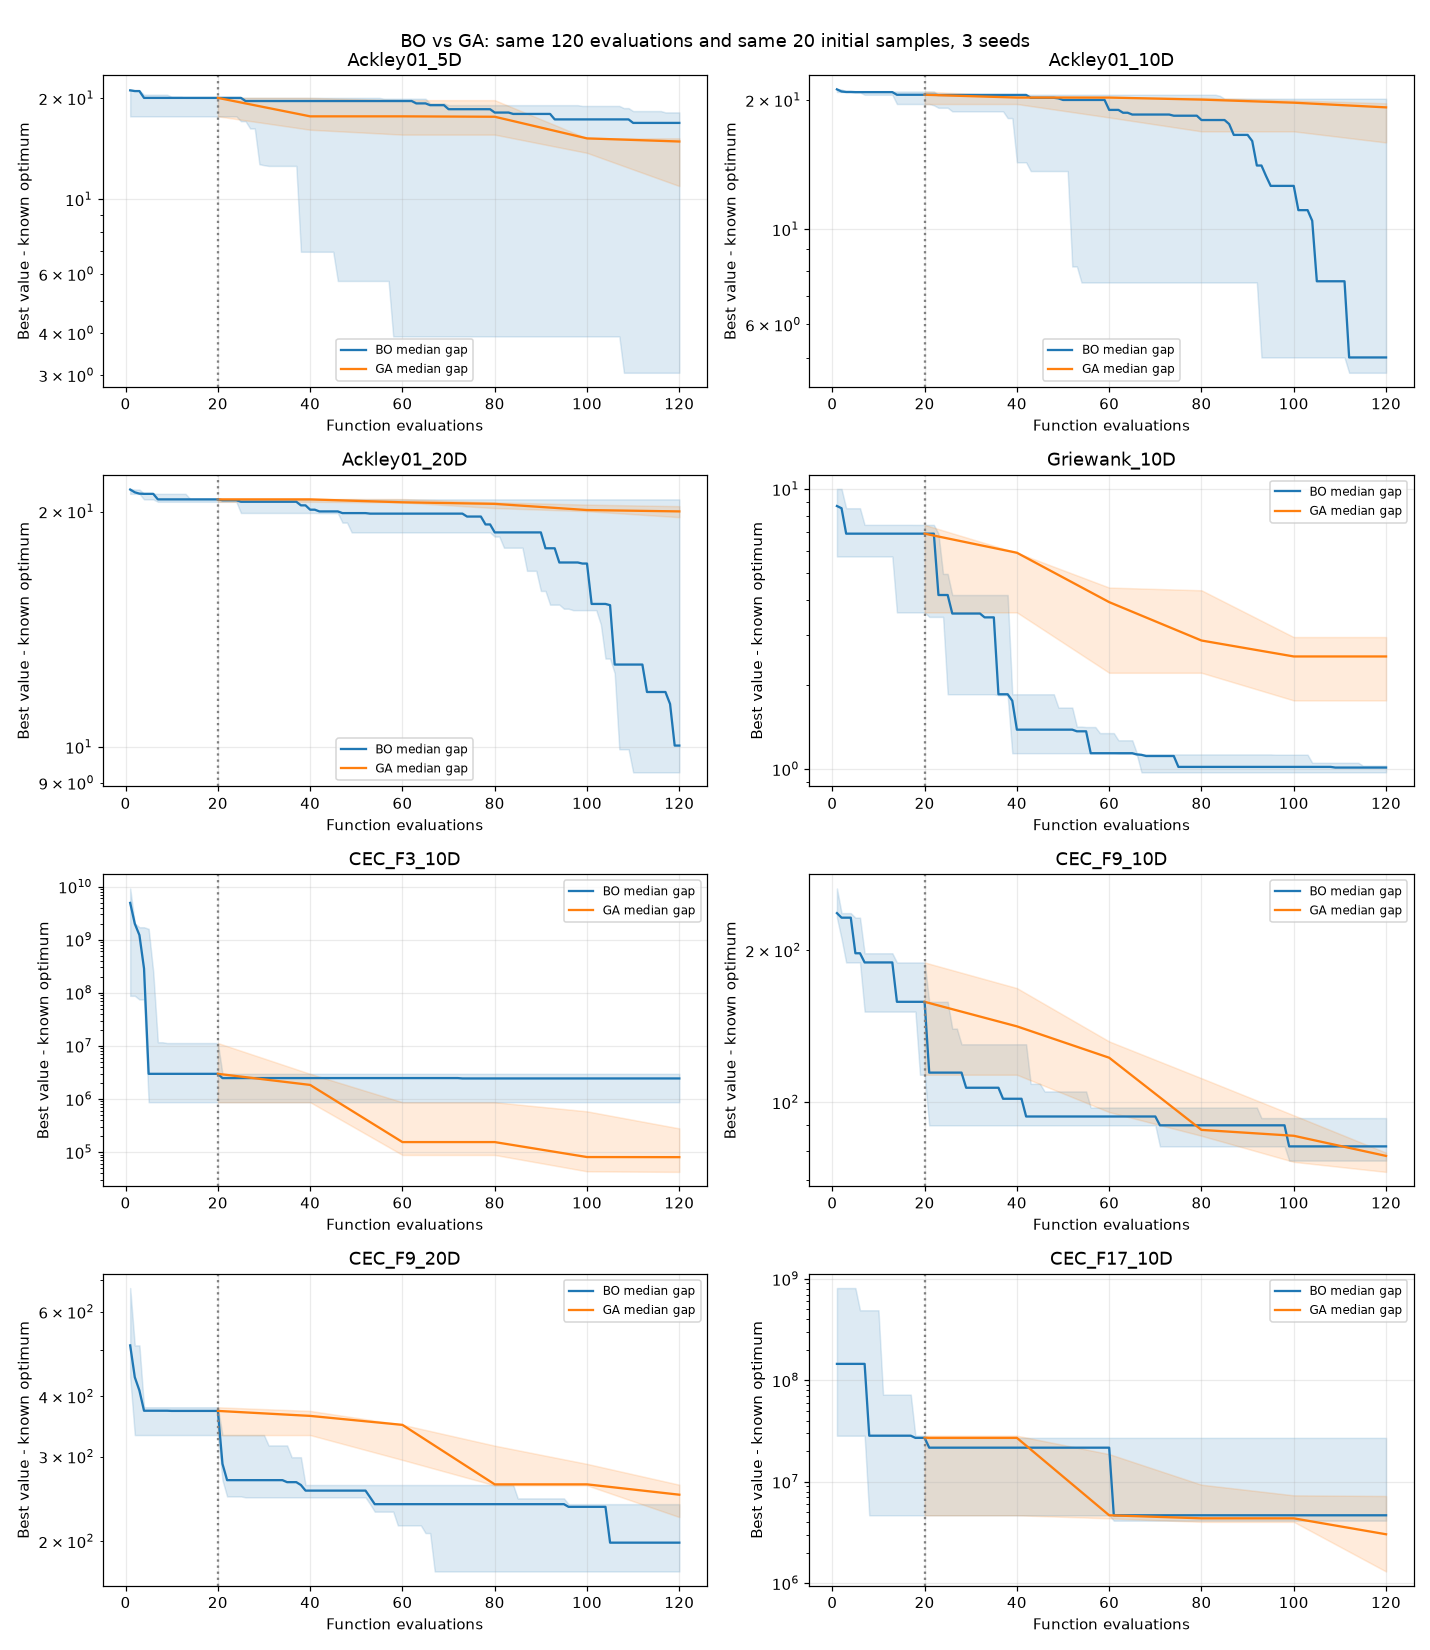

In [23]:
import matplotlib.pyplot as plt

equal_fig, equal_axes = plt.subplots(4, 2, figsize=(13, 15))
for equal_axis, (equal_name, _) in zip(equal_axes.flat, HIGH_CASES):
    case_equal_runs = [row for row in equal_runs if row["function"] == equal_name]
    equal_optimum = case_equal_runs[0]["known_optimum"]
    equal_counts = np.arange(1, EQUAL_BUDGET + 1)
    for method, color in [("bo", "tab:blue"), ("ga", "tab:orange")]:
        equal_gaps = np.asarray([row[f"{method}_best_history"] for row in case_equal_runs]) - equal_optimum
        if method == "ga":
            # GA 同一代的候选解批量产生，不将批内排序视为顺序决策。
            indices = np.arange(EQUAL_POP_SIZE - 1, EQUAL_BUDGET, EQUAL_POP_SIZE)
        else:
            indices = np.arange(EQUAL_BUDGET)
        equal_axis.plot(equal_counts[indices], np.maximum(np.median(equal_gaps, axis=0)[indices], 1e-12), color=color, label=f"{method.upper()} median gap")
        equal_axis.fill_between(
            equal_counts[indices], np.maximum(np.min(equal_gaps, axis=0)[indices], 1e-12),
            np.maximum(np.max(equal_gaps, axis=0)[indices], 1e-12), color=color, alpha=0.15,
        )
    equal_axis.axvline(EQUAL_POP_SIZE, color="gray", linestyle=":")
    equal_axis.set(title=equal_name, xlabel="Function evaluations", ylabel="Best value - known optimum", yscale="log")
    equal_axis.grid(alpha=0.25)
    equal_axis.legend(fontsize=8)
equal_fig.suptitle("BO vs GA: same 120 evaluations and same 20 initial samples, 3 seeds")
equal_fig.tight_layout()
plt.show()

In [24]:
import csv

equal_result_dir = Path("data")
equal_result_dir.mkdir(exist_ok=True)
equal_experiment = {
    "versions": {name: version(name) for name in ["pymoo", "bayesian-optimization", "opfunu", "numpy", "scipy"]},
    "settings": {
        "evaluations_per_run": EQUAL_BUDGET, "seeds": EQUAL_SEEDS,
        "shared_initial_points": EQUAL_POP_SIZE, "ga_pop_size": EQUAL_POP_SIZE,
        "ga_n_offsprings": EQUAL_POP_SIZE, "ga_crossover": "default SBX",
        "ga_mutation": "default PM", "ga_eliminate_duplicates": True,
        "bo_settings": equal_bo_data["settings"],
        "bo_source": "data/bayesian_optimization_highdim_results.json",
        "bounds": "opfunu full default bounds", "comparison": "minimize, median over seeds",
    },
    "summary": equal_summary, "runs": equal_runs,
}
equal_json_path = equal_result_dir / "bo_vs_ga_equal_budget.json"
equal_json_path.write_text(json.dumps(equal_experiment, ensure_ascii=False, indent=2) + "\n")
equal_csv_path = equal_result_dir / "bo_vs_ga_equal_budget.csv"
with equal_csv_path.open("w", newline="", encoding="utf-8") as equal_csv_file:
    equal_writer = csv.DictWriter(equal_csv_file, fieldnames=list(equal_summary[0]))
    equal_writer.writeheader()
    equal_writer.writerows(equal_summary)
print("同预算比较完整记录:", equal_json_path)
print("同预算比较汇总表:", equal_csv_path)

同预算比较完整记录: data/bo_vs_ga_equal_budget.json
同预算比较汇总表: data/bo_vs_ga_equal_budget.csv


### 同预算比较的结论

双方每次实际目标评估次数都是 120，且共享前 20 个随机初始化样本。以 3 个种子的中位数为主要比较指标：

- **BO 更好（4 组）**：Ackley 10D、Ackley 20D、Griewank 10D、CEC 旋转 Rastrigin 20D。
- **GA 更好（4 组）**：Ackley 5D、CEC Discus 10D、CEC 旋转 Rastrigin 10D、CEC 混合函数 F17 10D。
- Discus 上 GA 的中位数约 80567.70，BO 约 2435431.15，但两者都远高于最优值 300。
- CEC 旋转 Rastrigin 10D 的两个中位数接近：BO 981.752069、GA 978.275289。只有 3 次运行，不能将这点差异解释为可靠的整体优势。

这次结果显示不同函数偏好不同的搜索策略，没有一个算法在本次小预算下全面占优。主表比较的是中位数，并非各自挑选最好的一次；最好、最差及配对种子结果都保存在 JSON 中。

本次 GA 使用 20 个个体以共享 BO 的初始样本，与前一节种群 40 的实验是不同配置。此前 GA 6000 次的结果只能说明更多评估下的收敛情况，不能与 BO 120 次直接判断采样效率。相同目标评估预算也不代表相同运行时间：BO 建模和建议点计算仍有额外开销。


**基准校验更正**：本地 opfunu 1.0.1 的 F10 和 F17 使用了有异常的 modified Schwefel 实现：在默认边界内可得到低于标称全局最优值的数值。以前 F17 的原始数值比较仍对应本地实现，但最优值误差参照不可靠。本次主比较排除 F10/F17，分别使用旋转 Weierstrass F6 和混合函数 F19；完整可复现反例见 `data/optimization_suite_excluded_function.json`。未修改安装包。


## 扩展测试集：21 类函数、60 组组合，2–50 维

这部分是主要的综合比较，完整实现见同目录 `optimization_benchmark.py`。覆盖 **2、3、4、5、10、20、30、50 维**；每个函数只使用它支持的维度，不强行把固定维度函数扩展到高维。测试矩阵是有代表性的覆盖，并非把所有函数和所有维度做笛卡尔积。

函数包括 Chung–Reynolds、Cigar、Brown、Dixon–Price、Ackley、Griewank、Levy、Beale、Branin；CEC 2014 F1/F2/F3/F4/F5/F7/F9/F10/F17/F23；以及分段不连续的 Corana 和具有极窄最优区域的 NeedleEye。类别标签描述主要结构，不直接使用 opfunu 的所有布尔标记，以避免把默认继承值当作可靠的数学分类。

**统一规则**：BO、GA、随机搜索每次均为 **120 次目标评估**，种子 `0, 1, 42`，共用 **20 个初始点**，完整默认边界。GA 种群/子代均为 20，BO 使用 UCB（kappa=2.576）及原来的默认 GP/采集函数优化设置。总计 **180 个配对种子实验**，另有 180 次随机搜索参考。旧的相同配置实验通过验证后复用；新增实验在独立 Python 进程中计算，随机状态互不影响。

每组先检查维度、边界、已知最优解处的函数值，再核对每个算法实际求值次数、共享初始点与返回解。每次完成即缓存，重复运行可以继续；结果文件记录软件版本、配置和缓存指纹。

主要指标是三个种子的目标值/最优值误差中位数。跨函数汇总时使用 **最终误差 ÷ 本次初始化最好点的误差**，再对种子取中位数，越小代表比起点改进越大，避免直接平均不同尺度的原始目标值。随机搜索也只看到相同的随机初始化点，不使用已知最优解。这里只测试无约束（除搜索边界）、单目标、确定性函数；不包含多目标、噪声和离散变量。

In [ ]:
import json
from pathlib import Path
import numpy as np
from IPython.display import Markdown, display
from optimization_benchmark import make_cases, configuration, run_suite

suite_path = Path("data/optimization_suite_results.json")
suite_cases = make_cases()
suite_data: dict = {}
if suite_path.exists():
    suite_data = json.loads(suite_path.read_text())
    if suite_data.get("configuration") != configuration() or [row["name"] for row in suite_data["cases"]] != [case.name for case in suite_cases]:
        suite_data = {}
if not suite_data:
    suite_data = run_suite(workers=4)

suite_summary: list[dict] = suite_data["summary"]
suite_runs: list[dict] = suite_data["runs"]
assert len(suite_summary) == 60 and len(suite_runs) == 180
assert all(row["evaluations"] == 120 for row in suite_runs)
print("函数族:", len({row["family"] for row in suite_summary}))
print("函数与维度组合:", len(suite_summary))
print("配对种子实验:", len(suite_runs))
print("BO / GA / 随机搜索每次评估次数:", suite_data["configuration"]["budget"])
print("详细实现与配置:", Path("optimization_benchmark.py"))

In [ ]:
suite_dimensions = sorted({case.ndim for case in suite_cases})
suite_families = list(dict.fromkeys(case.family for case in suite_cases))
coverage_header = "| 函数族 | 类型 | " + " | ".join(f"{d}维" for d in suite_dimensions) + " |"
coverage_lines = [coverage_header, "|---|---|" + "---|" * len(suite_dimensions)]
for family in suite_families:
    family_cases = [case for case in suite_cases if case.family == family]
    supported_dimensions = {case.ndim for case in family_cases}
    marks = ["✓" if d in supported_dimensions else "—" for d in suite_dimensions]
    coverage_lines.append("| " + " | ".join([family, family_cases[0].category, *marks]) + " |")
display(Markdown("### 测试覆盖矩阵\n\n" + "\n".join(coverage_lines)))

In [ ]:
suite_result_lines = [
    "| 函数 | 维度 | 已知最优值 | BO 中位数 | GA 中位数 | 随机搜索中位数 | BO/GA 更好 |",
    "|---|---:|---:|---:|---:|---:|---|",
]
for row in suite_summary:
    suite_result_lines.append(
        f"| {row['family']} | {row['ndim']} | {row['known_optimum']:.6g} "
        f"| {row['bo_median']:.6g} | {row['ga_median']:.6g} "
        f"| {row['random_median']:.6g} | {row['winner']} |"
    )
display(Markdown("### 全部 60 组同预算结果\n\n" + "\n".join(suite_result_lines)))
print("BO 胜:", sum(row["winner"] == "BO" for row in suite_summary))
print("GA 胜:", sum(row["winner"] == "GA" for row in suite_summary))
print("近似平局:", sum(row["winner"] == "Tie" for row in suite_summary))

In [ ]:
suite_group_lines = [
    "| 分组方式 | 分组 | 组数 | BO 胜 | GA 胜 | 平局 | BO 相对误差 | GA 相对误差 | 随机搜索相对误差 |",
    "|---|---|---:|---:|---:|---:|---:|---:|---:|",
]
for group in suite_data["groups"]:
    suite_group_lines.append(
        f"| {group['group_by']} | {group['group']} | {group['cases']} "
        f"| {group['bo_wins']} | {group['ga_wins']} | {group['ties']} "
        f"| {group['bo_median_relative_gap']:.4g} "
        f"| {group['ga_median_relative_gap']:.4g} | {group['random_median_relative_gap']:.4g} |"
    )
display(Markdown("### 按维度和结构类型汇总\n\n" + "\n".join(suite_group_lines)))
print("相对误差为最终误差/初始化误差；分组数字是各组相对误差的中位数。")
print("不同函数尺度、类型及组合数量不同；胜场计数只描述本测试集，不代表普遍优劣。")

In [ ]:
import matplotlib.pyplot as plt

suite_overview_fig, suite_overview_axes = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={"width_ratios": [2.2, 1]})
suite_heatmap = np.full((len(suite_families), len(suite_dimensions)), np.nan)
for row in suite_summary:
    family_index = suite_families.index(row["family"])
    dimension_index = suite_dimensions.index(row["ndim"])
    gap_floor = 1e-12 * max(1.0, row["initial_gap_median"])
    suite_heatmap[family_index, dimension_index] = np.log10(
        max(row["ga_gap_median"], gap_floor) / max(row["bo_gap_median"], gap_floor)
    )
suite_cmap = plt.get_cmap("RdBu_r").copy()
suite_cmap.set_bad("#eeeeee")
suite_image = suite_overview_axes[0].imshow(suite_heatmap, cmap=suite_cmap, vmin=-3, vmax=3, aspect="auto")
suite_overview_axes[0].set_xticks(range(len(suite_dimensions)), suite_dimensions)
suite_overview_axes[0].set_yticks(range(len(suite_families)), suite_families)
suite_overview_axes[0].set(xlabel="Dimensions", title="Median gap ratio: blue = GA lower, red = BO lower")
for row_index in range(len(suite_families)):
    for column_index in range(len(suite_dimensions)):
        heat_value = suite_heatmap[row_index, column_index]
        if np.isfinite(heat_value):
            suite_overview_axes[0].text(column_index, row_index, f"{heat_value:.1f}", ha="center", va="center", fontsize=8, color="white" if abs(heat_value) > 1.5 else "black")
suite_overview_fig.colorbar(suite_image, ax=suite_overview_axes[0], shrink=0.65, label="log10(GA gap / BO gap), colors clipped to [-3, 3]")
suite_bands = ["low (2-5)", "medium (10-20)", "high (30-50)"]
suite_band_rows = [next(group for group in suite_data["groups"] if group["group_by"] == "dimension_band" and group["group"] == band) for band in suite_bands]
suite_y = np.arange(len(suite_bands))
suite_bo_wins = np.asarray([row["bo_wins"] for row in suite_band_rows])
suite_ga_wins = np.asarray([row["ga_wins"] for row in suite_band_rows])
suite_ties = np.asarray([row["ties"] for row in suite_band_rows])
suite_overview_axes[1].barh(suite_y, suite_bo_wins, label="BO", color="tab:blue")
suite_overview_axes[1].barh(suite_y, suite_ga_wins, left=suite_bo_wins, label="GA", color="tab:orange")
suite_overview_axes[1].barh(suite_y, suite_ties, left=suite_bo_wins + suite_ga_wins, label="Tie", color="gray")
suite_overview_axes[1].set_yticks(suite_y, suite_bands)
suite_overview_axes[1].set(xlabel="Number of cases", title="Wins by dimension band")
suite_overview_axes[1].legend()
suite_overview_axes[1].grid(axis="x", alpha=0.2)
suite_overview_fig.suptitle("60 cases, 21 function families, same 120 evaluations and 20 initial points")
suite_overview_fig.tight_layout()
suite_overview_fig.savefig("data/optimization_suite_overview.png", dpi=150)
plt.show()

In [ ]:
suite_selected = [
    "ChungReynolds_2D", "Cigar_10D", "Ackley01_10D", "Ackley01_50D",
    "CEC_F9_10D", "CEC_F9_50D", "CEC_F19_30D", "Corana_4D",
]
suite_curves_fig, suite_curves_axes = plt.subplots(4, 2, figsize=(13, 15))
for curve_axis, selected_case in zip(suite_curves_axes.flat, suite_selected):
    selected_runs = [row for row in suite_runs if row["case"] == selected_case]
    selected_optimum = selected_runs[0]["known_optimum"]
    selected_counts = np.arange(1, 121)
    for method, color in [("bo", "tab:blue"), ("ga", "tab:orange"), ("random", "tab:green")]:
        selected_gaps = np.asarray([row[f"{method}_history"] for row in selected_runs]) - selected_optimum
        selected_indices = np.arange(19, 120, 20) if method == "ga" else np.arange(120)
        curve_axis.plot(selected_counts[selected_indices], np.maximum(np.median(selected_gaps, axis=0)[selected_indices], 1e-12), label=method.upper(), color=color)
        curve_axis.fill_between(
            selected_counts[selected_indices], np.maximum(np.min(selected_gaps, axis=0)[selected_indices], 1e-12),
            np.maximum(np.max(selected_gaps, axis=0)[selected_indices], 1e-12), alpha=0.10, color=color,
        )
    curve_axis.axvline(20, color="gray", linestyle=":")
    curve_axis.set(title=selected_case, xlabel="Function evaluations", ylabel="Best value - known optimum", yscale="log")
    curve_axis.grid(alpha=0.25)
    curve_axis.legend(fontsize=8)
suite_curves_fig.suptitle("Selected convergence curves: median and range across 3 seeds")
suite_curves_fig.tight_layout()
suite_curves_fig.savefig("data/optimization_suite_convergence.png", dpi=130)
plt.show()
print("全部结果:", suite_path)
print("每组汇总:", Path("data/optimization_suite_summary.csv"))
print("按维度/类型汇总:", Path("data/optimization_suite_groups.csv"))
print("每个种子的结果:", Path("data/optimization_suite_runs.csv"))